<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-255-Data-Mining/blob/main/MovieLensDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()   # picks file from your Mac

Saving xkgrank_save.zip to xkgrank_save.zip


In [3]:
import zipfile
with zipfile.ZipFile("/content/xkgrank_save.zip") as zf:
    zf.extractall("/content/")

import os
DATA = "/content/xkgrank_save/"
print(f"Files in {DATA}:")
for f in sorted(os.listdir(DATA)):
    print(f"   {f}")

Files in /content/xkgrank_save/:
   all_movie_ids.json
   all_user_ids.json
   df_movies.csv
   df_ratings.csv
   df_test.csv
   df_train.csv
   df_users.csv
   df_valid.csv
   edge_index.pt
   item2idx.json
   kg_graph.pkl
   sizes.json
   user2idx.json


In [4]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:    {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing: {device}")

CUDA available: True
GPU:    NVIDIA RTX PRO 6000 Blackwell Server Edition
Memory: 102.0 GB

Using: cuda


In [5]:
!pip install torch-geometric -q
print("✅ torch-geometric installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.2 MB/s eta 0:00:00
✅ torch-geometric installed


In [9]:
import pandas as pd
import json
import pickle
from collections import defaultdict

# DataFrames
df_train  = pd.read_csv(f"{DATA}df_train.csv")
df_valid  = pd.read_csv(f"{DATA}df_valid.csv")
df_test   = pd.read_csv(f"{DATA}df_test.csv")
df_movies = pd.read_csv(f"{DATA}df_movies.csv")

# Mappings — convert string keys back to int
with open(f"{DATA}user2idx.json") as f:
    user2idx = {int(k): v for k, v in json.load(f).items()}
with open(f"{DATA}item2idx.json") as f:
    item2idx = {int(k): v for k, v in json.load(f).items()}
with open(f"{DATA}all_user_ids.json") as f:
    all_user_ids = json.load(f)
with open(f"{DATA}all_movie_ids.json") as f:
    all_movie_ids = json.load(f)
with open(f"{DATA}sizes.json") as f:
    sizes = json.load(f)

n_users   = sizes['n_users']
n_items   = sizes['n_items']
num_nodes = sizes['num_nodes']

# edge_index → GPU
edge_index = torch.load(f"{DATA}edge_index.pt").to(device)

# NetworkX graph
with open(f"{DATA}kg_graph.pkl", 'rb') as f:
    G = pickle.load(f)

print("✅ Everything reloaded")
print(f"   Train: {len(df_train):,} | Valid: {len(df_valid):,} | Test: {len(df_test):,}")
print(f"   Users: {n_users:,} | Movies: {n_items:,} | Total nodes: {num_nodes:,}")
print(f"   edge_index: {edge_index.shape} on {edge_index.device}")
print(f"   Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

✅ Everything reloaded
   Train: 988,129 | Valid: 6,040 | Test: 6,040
   Users: 6,040 | Movies: 3,704 | Total nodes: 9,744
   edge_index: torch.Size([2, 1976258]) on cuda:0
   Graph: 9,762 nodes, 999,264 edges


In [10]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import LGConv

class LightGCN(nn.Module):
    def __init__(self, num_nodes, embedding_dim=64, num_layers=3):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, embedding_dim)
        self.convs     = nn.ModuleList([LGConv() for _ in range(num_layers)])
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, edge_index):
        x = self.embedding.weight
        embs = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            embs.append(x)
        return F.normalize(torch.stack(embs, dim=1).mean(dim=1), p=2, dim=-1)

    def bpr_loss(self, u, p, n, reg=1e-4):
        pos = (u * p).sum(dim=1)
        neg = (u * n).sum(dim=1)
        bpr = -F.logsigmoid(pos - neg).mean()
        return bpr + reg * (u.norm(2).pow(2) + p.norm(2).pow(2) + n.norm(2).pow(2)) / u.shape[0]

# Tuned hyperparameters for MovieLens-1M
EMBEDDING_DIM = 64
NUM_LAYERS    = 3
EPOCHS        = 100
BATCH_SIZE    = 4096
PATIENCE      = 8

model     = LightGCN(num_nodes, EMBEDDING_DIM, NUM_LAYERS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-4)

print(f"✅ Model on {device}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

✅ Model on cuda
   Parameters: 623,616


In [11]:
import numpy as np
import time

u_pos_items = defaultdict(set)
for _, row in df_train.iterrows():
    u_pos_items[row['user_id']].add(row['movie_id'])

train_pairs = [(row['user_id'], row['movie_id'])
               for _, row in df_train.iterrows()
               if row['user_id'] in user2idx and row['movie_id'] in item2idx]

u_all = torch.tensor([user2idx[u] for u,_ in train_pairs], dtype=torch.long).to(device)
p_all = torch.tensor([item2idx[m] for _,m in train_pairs], dtype=torch.long).to(device)
item_idx_tensor = torch.tensor(list(item2idx.values()), dtype=torch.long).to(device)
n_pairs = len(u_all)

val_gt = defaultdict(set)
for _, row in df_valid.iterrows():
    val_gt[row['user_id']].add(row['movie_id'])

print(f"✅ Training: {n_pairs:,} pairs on {device}")
print(f"   Items: {len(item_idx_tensor):,}")
print(f"   Val users: {len(val_gt):,}")

✅ Training: 988,129 pairs on cuda
   Items: 3,704
   Val users: 6,040


In [12]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import LGConv

class LightGCN(nn.Module):
    def __init__(self, num_nodes, embedding_dim=64, num_layers=3, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, embedding_dim)
        self.convs     = nn.ModuleList([LGConv() for _ in range(num_layers)])
        self.dropout   = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, edge_index):
        x = self.dropout(self.embedding.weight)
        embs = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            embs.append(x)
        return F.normalize(torch.stack(embs, dim=1).mean(dim=1), p=2, dim=-1)

    def bpr_loss(self, u, p, n, reg=1e-4):
        pos = (u * p).sum(dim=1)
        neg = (u * n).sum(dim=1)
        bpr = -F.logsigmoid(pos - neg).mean()
        return bpr + reg * (u.norm(2).pow(2) + p.norm(2).pow(2) + n.norm(2).pow(2)) / u.shape[0]

# BIGGER model — H100 can easily handle this
EMBEDDING_DIM = 128       # ↑ from 64
NUM_LAYERS    = 3
EPOCHS        = 200       # ↑ from 100
BATCH_SIZE    = 8192      # ↑ from 4096 (H100 has 80GB!)
PATIENCE      = 15        # ↑ from 8 (less aggressive early stop)
LR            = 0.001
WEIGHT_DECAY  = 1e-5      # ↓ from 1e-4 (less regularization on dense data)

model     = LightGCN(num_nodes, EMBEDDING_DIM, NUM_LAYERS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

print(f"✅ Model — {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"   Embedding dim: {EMBEDDING_DIM}")
print(f"   Layers:        {NUM_LAYERS}")
print(f"   Max epochs:    {EPOCHS}")
print(f"   Batch size:    {BATCH_SIZE}")
print(f"   LR:            {LR}")
print(f"   Weight decay:  {WEIGHT_DECAY}")

✅ Model — 1,247,232 parameters
   Embedding dim: 128
   Layers:        3
   Max epochs:    200
   Batch size:    8192
   LR:            0.001
   Weight decay:  1e-05


In [13]:
import pandas as pd

df_ratings = pd.read_csv(f"{DATA}df_ratings.csv")
print(f"✅ df_ratings loaded: {df_ratings.shape}")
print(df_ratings.head(3))

✅ df_ratings loaded: (1000209, 4)
   user_id  movie_id  rating  timestamp
0        1      3186       4  978300019
1        1      1270       5  978300055
2        1      1721       4  978300055


In [14]:
import numpy as np
import pandas as pd

np.random.seed(42)
print("Re-splitting with random leave-one-out (standard for MovieLens-1M)...")

# Filter users with enough ratings
user_counts = df_ratings.groupby('user_id').size()
valid_users = user_counts[user_counts >= 10].index
df_full = df_ratings[df_ratings['user_id'].isin(valid_users)].copy()
print(f"Users with ≥10 ratings: {len(valid_users):,}")

# RANDOM leave-one-out (not time-based)
test_idx, valid_idx, train_idx = [], [], []
for user_id, group in df_full.groupby('user_id'):
    indices = group.index.tolist()
    np.random.shuffle(indices)
    test_idx.append(indices[0])
    valid_idx.append(indices[1])
    train_idx.extend(indices[2:])

df_test  = df_full.loc[test_idx].reset_index(drop=True)
df_valid = df_full.loc[valid_idx].reset_index(drop=True)
df_train = df_full.loc[train_idx].reset_index(drop=True)

print(f"\nTrain: {df_train.shape}")
print(f"Valid: {df_valid.shape}")
print(f"Test:  {df_test.shape}")
print(f"Users: {df_train['user_id'].nunique():,}")
print(f"Items: {df_train['movie_id'].nunique():,}")

Re-splitting with random leave-one-out (standard for MovieLens-1M)...
Users with ≥10 ratings: 6,040

Train: (988129, 4)
Valid: (6040, 4)
Test:  (6040, 4)
Users: 6,040
Items: 3,704


In [15]:
import numpy as np
import pandas as pd

np.random.seed(42)
print("Re-splitting with random leave-one-out (standard for MovieLens-1M)...")

# Filter users with enough ratings
user_counts = df_ratings.groupby('user_id').size()
valid_users = user_counts[user_counts >= 10].index
df_full = df_ratings[df_ratings['user_id'].isin(valid_users)].copy()
print(f"Users with ≥10 ratings: {len(valid_users):,}")

# RANDOM leave-one-out (not time-based)
test_idx, valid_idx, train_idx = [], [], []
for user_id, group in df_full.groupby('user_id'):
    indices = group.index.tolist()
    np.random.shuffle(indices)
    test_idx.append(indices[0])
    valid_idx.append(indices[1])
    train_idx.extend(indices[2:])

df_test  = df_full.loc[test_idx].reset_index(drop=True)
df_valid = df_full.loc[valid_idx].reset_index(drop=True)
df_train = df_full.loc[train_idx].reset_index(drop=True)

print(f"\nTrain: {df_train.shape}")
print(f"Valid: {df_valid.shape}")
print(f"Test:  {df_test.shape}")
print(f"Users: {df_train['user_id'].nunique():,}")
print(f"Items: {df_train['movie_id'].nunique():,}")

Re-splitting with random leave-one-out (standard for MovieLens-1M)...
Users with ≥10 ratings: 6,040

Train: (988129, 4)
Valid: (6040, 4)
Test:  (6040, 4)
Users: 6,040
Items: 3,704


In [16]:
from collections import defaultdict
from torch_geometric.utils import to_undirected

# Rebuild mappings
all_user_ids   = sorted(df_train['user_id'].unique())
all_movie_ids  = sorted(df_train['movie_id'].unique())
n_users        = len(all_user_ids)
n_items        = len(all_movie_ids)

user2idx = {uid: i for i, uid in enumerate(all_user_ids)}
item2idx = {mid: i + n_users for i, mid in enumerate(all_movie_ids)}
num_nodes = n_users + n_items

# Rebuild edge_index
edge_src, edge_tgt = [], []
for _, row in df_train.iterrows():
    if row['user_id'] in user2idx and row['movie_id'] in item2idx:
        u = user2idx[row['user_id']]
        i = item2idx[row['movie_id']]
        edge_src += [u, i]
        edge_tgt += [i, u]
edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long).to(device)

# Rebuild training pairs
u_pos_items = defaultdict(set)
for _, row in df_train.iterrows():
    u_pos_items[row['user_id']].add(row['movie_id'])

train_pairs = [(row['user_id'], row['movie_id'])
               for _, row in df_train.iterrows()
               if row['user_id'] in user2idx and row['movie_id'] in item2idx]
u_all = torch.tensor([user2idx[u] for u,_ in train_pairs], dtype=torch.long).to(device)
p_all = torch.tensor([item2idx[m] for _,m in train_pairs], dtype=torch.long).to(device)
item_idx_tensor = torch.tensor(list(item2idx.values()), dtype=torch.long).to(device)
n_pairs = len(u_all)

# Rebuild val ground truth
val_gt = defaultdict(set)
for _, row in df_valid.iterrows():
    val_gt[row['user_id']].add(row['movie_id'])

# Rebuild eval tensors
movie_id_to_pos = {mid: i for i, mid in enumerate(all_movie_ids)}
n_movies = len(all_movie_ids)

val_users_list = [u for u in val_gt.keys() if u in user2idx]
val_user_idx_t = torch.tensor([user2idx[u] for u in val_users_list], dtype=torch.long, device=device)

seen_mask_val = torch.zeros((len(val_users_list), n_movies), dtype=torch.bool, device=device)
for i, uid in enumerate(val_users_list):
    for mid in u_pos_items[uid]:
        if mid in movie_id_to_pos:
            seen_mask_val[i, movie_id_to_pos[mid]] = True

val_gt_idx = []
for uid in val_users_list:
    gt_mids = [movie_id_to_pos[m] for m in val_gt[uid] if m in movie_id_to_pos]
    val_gt_idx.append(set(gt_mids))

print(f"✅ Rebuilt — {n_pairs:,} train pairs, {len(val_users_list):,} val users")
print(f"   edge_index: {edge_index.shape}")

✅ Rebuilt — 988,129 train pairs, 6,040 val users
   edge_index: torch.Size([2, 1976258])


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import LGConv
import numpy as np
import time

class LightGCN(nn.Module):
    def __init__(self, num_nodes, embedding_dim=64, num_layers=3):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, embedding_dim)
        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])
        nn.init.normal_(self.embedding.weight, std=0.1)   # standard init for LightGCN

    def forward(self, edge_index):
        x = self.embedding.weight
        embs = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            embs.append(x)
        return torch.stack(embs, dim=1).mean(dim=1)


# ── REBUILD edge_index — UNDIRECTED only (don't manually add reverse) ─────
print("Rebuilding edge_index (single direction)...")
edge_src, edge_tgt = [], []
for _, row in df_train.iterrows():
    if row['user_id'] in user2idx and row['movie_id'] in item2idx:
        edge_src.append(user2idx[row['user_id']])
        edge_tgt.append(item2idx[row['movie_id']])

# Make undirected via PyG utility (correct way)
from torch_geometric.utils import to_undirected
edge_index_dir = torch.tensor([edge_src, edge_tgt], dtype=torch.long)
edge_index = to_undirected(edge_index_dir).to(device)
print(f"✅ edge_index: {edge_index.shape}")


# ── Hyperparameters (from published LightGCN paper) ──
EMBEDDING_DIM = 64
NUM_LAYERS    = 3
EPOCHS        = 200
BATCH_SIZE    = 2048
PATIENCE      = 30
LR            = 0.001
L2_REG        = 1e-4

model = LightGCN(num_nodes, EMBEDDING_DIM, NUM_LAYERS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


# ── TRAIN — proper per-batch forward/backward ──
best_ndcg, patience_ctr, best_weights = 0.0, 0, None
train_losses, val_ndcgs, val_recalls, val_epochs = [], [], [], []

print(f"\nTraining canonical LightGCN — {n_pairs:,} pairs\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()

    # Shuffle once per epoch
    perm = torch.randperm(n_pairs, device=device)
    u_shuf = u_all[perm]
    p_shuf = p_all[perm]
    n_shuf = item_idx_tensor[torch.randint(0, len(item_idx_tensor), (n_pairs,), device=device)]

    total_loss = 0.0
    n_batches = 0

    for start in range(0, n_pairs, BATCH_SIZE):
        u_b = u_shuf[start:start+BATCH_SIZE]
        p_b = p_shuf[start:start+BATCH_SIZE]
        n_b = n_shuf[start:start+BATCH_SIZE]

        # ✅ Forward INSIDE the batch loop
        optimizer.zero_grad()
        embs = model(edge_index)

        u_e = embs[u_b]
        p_e = embs[p_b]
        n_e = embs[n_b]

        # BPR loss
        pos_scores = (u_e * p_e).sum(dim=1)
        neg_scores = (u_e * n_e).sum(dim=1)
        bpr_loss = -F.logsigmoid(pos_scores - neg_scores).mean()

        # L2 reg on raw embedding lookup (not propagated)
        raw_u = model.embedding(u_b)
        raw_p = model.embedding(p_b)
        raw_n = model.embedding(n_b)
        reg_loss = L2_REG * (raw_u.norm(2).pow(2) + raw_p.norm(2).pow(2) + raw_n.norm(2).pow(2)) / (2 * len(u_b))

        loss = bpr_loss + reg_loss
        loss.backward()       # ✅ NO retain_graph
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    avg_loss = total_loss / n_batches
    train_losses.append(avg_loss)

    # ── Eval every 5 epochs ──
    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            embs_eval = model(edge_index)
            item_embs = embs_eval[item_idx_tensor]
            user_embs = embs_eval[val_user_idx_t]
            scores    = user_embs @ item_embs.T
            scores[seen_mask_val] = -9999.0
            top10_idx = scores.topk(10, dim=1).indices.cpu().numpy()

        val_ndcg_list, val_recall_list = [], []
        for i, gt_set in enumerate(val_gt_idx):
            if not gt_set: continue
            recs = top10_idx[i]
            hits = sum(1 for r in recs if int(r) in gt_set)
            dcg  = sum(1/np.log2(r+2) for r,it in enumerate(recs) if int(it) in gt_set)
            idcg = sum(1/np.log2(r+2) for r in range(min(len(gt_set), 10)))
            val_ndcg_list.append(dcg/idcg if idcg > 0 else 0.0)
            val_recall_list.append(hits / len(gt_set))

        val_ndcg = np.mean(val_ndcg_list)
        val_recall = np.mean(val_recall_list)
        val_ndcgs.append(val_ndcg)
        val_recalls.append(val_recall)
        val_epochs.append(epoch)

        if val_ndcg > best_ndcg:
            best_ndcg = val_ndcg
            best_weights = {k: v.clone() for k,v in model.state_dict().items()}
            patience_ctr = 0
            flag = "✅ BEST"
        else:
            patience_ctr += 1
            flag = f"patience {patience_ctr}/{PATIENCE}"

        print(f"Epoch {epoch:>3}/{EPOCHS} | Loss: {avg_loss:.4f} | "
              f"NDCG@10: {val_ndcg:.4f} | Recall@10: {val_recall:.4f} | "
              f"{time.time()-t0:.1f}s | {flag}")

        if patience_ctr >= PATIENCE:
            print(f"\n⏹ Early stop — best NDCG@10: {best_ndcg:.4f}")
            break

if best_weights:
    model.load_state_dict(best_weights)
model.eval()
with torch.no_grad():
    final_embeddings = model(edge_index)

print(f"\n✅ Training complete — best Val NDCG@10: {best_ndcg:.4f}")

Rebuilding edge_index (single direction)...
✅ edge_index: torch.Size([2, 1976258])

Training canonical LightGCN — 988,129 pairs

Epoch   5/200 | Loss: 0.3840 | NDCG@10: 0.0418 | Recall@10: 0.0790 | 7.2s | ✅ BEST
Epoch  10/200 | Loss: 0.3276 | NDCG@10: 0.0664 | Recall@10: 0.1189 | 7.0s | ✅ BEST
Epoch  15/200 | Loss: 0.3026 | NDCG@10: 0.0735 | Recall@10: 0.1310 | 7.0s | ✅ BEST
Epoch  20/200 | Loss: 0.2876 | NDCG@10: 0.0789 | Recall@10: 0.1434 | 7.0s | ✅ BEST
Epoch  25/200 | Loss: 0.2781 | NDCG@10: 0.0838 | Recall@10: 0.1528 | 7.0s | ✅ BEST
Epoch  30/200 | Loss: 0.2702 | NDCG@10: 0.0882 | Recall@10: 0.1626 | 7.0s | ✅ BEST
Epoch  35/200 | Loss: 0.2642 | NDCG@10: 0.0910 | Recall@10: 0.1672 | 7.0s | ✅ BEST
Epoch  40/200 | Loss: 0.2583 | NDCG@10: 0.0915 | Recall@10: 0.1684 | 7.0s | ✅ BEST
Epoch  45/200 | Loss: 0.2540 | NDCG@10: 0.0940 | Recall@10: 0.1730 | 7.0s | ✅ BEST
Epoch  50/200 | Loss: 0.2504 | NDCG@10: 0.0937 | Recall@10: 0.1740 | 7.0s | patience 1/30
Epoch  55/200 | Loss: 0.2478 | NDC

In [20]:
# ═══════════════════════════════════════════════════════════════
#  CELL 1 — Evaluation: LightGCN
# ═══════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, torch
import torch.nn.functional as F
from IPython.display import display
import warnings; warnings.filterwarnings('ignore')

Ks = [5, 10, 20]

def evaluate_model(embs, user_idx_t, item_idx_t, seen_mask, gt_idx_list, ks=Ks):
    results = {f'NDCG@{k}':[] for k in ks}
    results.update({f'Recall@{k}':[] for k in ks})
    results.update({f'Precision@{k}':[] for k in ks})
    results.update({f'HR@{k}':[] for k in ks})
    mrr_list = []

    with torch.no_grad():
        scores = embs[user_idx_t] @ embs[item_idx_t].T
        scores[seen_mask] = -9999.0
        topk_idx = scores.topk(max(ks), dim=1).indices.cpu().numpy()

    for i, gt_set in enumerate(gt_idx_list):
        if not gt_set: continue
        recs = topk_idx[i]
        mrr_list.append(next((1/(r+1) for r,it in enumerate(recs) if int(it) in gt_set), 0.0))
        for k in ks:
            recs_k = recs[:k]
            hits    = sum(1 for r in recs_k if int(r) in gt_set)
            dcg     = sum(1/np.log2(r+2) for r,it in enumerate(recs_k) if int(it) in gt_set)
            idcg    = sum(1/np.log2(r+2) for r in range(min(len(gt_set), k)))
            results[f'NDCG@{k}'].append(dcg/idcg if idcg else 0.0)
            results[f'Recall@{k}'].append(hits/len(gt_set))
            results[f'Precision@{k}'].append(hits/k)
            results[f'HR@{k}'].append(1.0 if hits > 0 else 0.0)

    results['MRR'] = mrr_list
    return {k: float(np.mean(v)) for k,v in results.items()}

# ── LightGCN ──────────────────────────────────────────────────────────────────
print('Evaluating LightGCN ...', end='  ')
model.eval()
with torch.no_grad():
    lgcn_embs = model(edge_index)
lgcn_scores = evaluate_model(lgcn_embs, val_user_idx_t, item_idx_tensor,
                              seen_mask_val, val_gt_idx)
print('done\n')

# ── Table ─────────────────────────────────────────────────────────────────────
metrics = ['NDCG@5','NDCG@10','NDCG@20',
           'Recall@5','Recall@10','Recall@20',
           'Precision@10','HR@10','MRR']

df_eval = pd.DataFrame({
    'LightGCN': [lgcn_scores[m] for m in metrics],
}, index=metrics).round(4)

print('══════ Validation Results ══════')
display(df_eval.style.format('{:.4f}'))

all_model_embs = {'LightGCN': lgcn_embs}
print('\n✅ Ready for Cells 2–5')

Evaluating LightGCN ...  done

══════ Validation Results ══════


,LightGCN
NDCG@5,0.0821
NDCG@10,0.1061
NDCG@20,0.1289
Recall@5,0.1257
Recall@10,0.2002
Recall@20,0.2909
Precision@10,0.0200
HR@10,0.2002
MRR,0.0839



✅ Ready for Cells 2–5


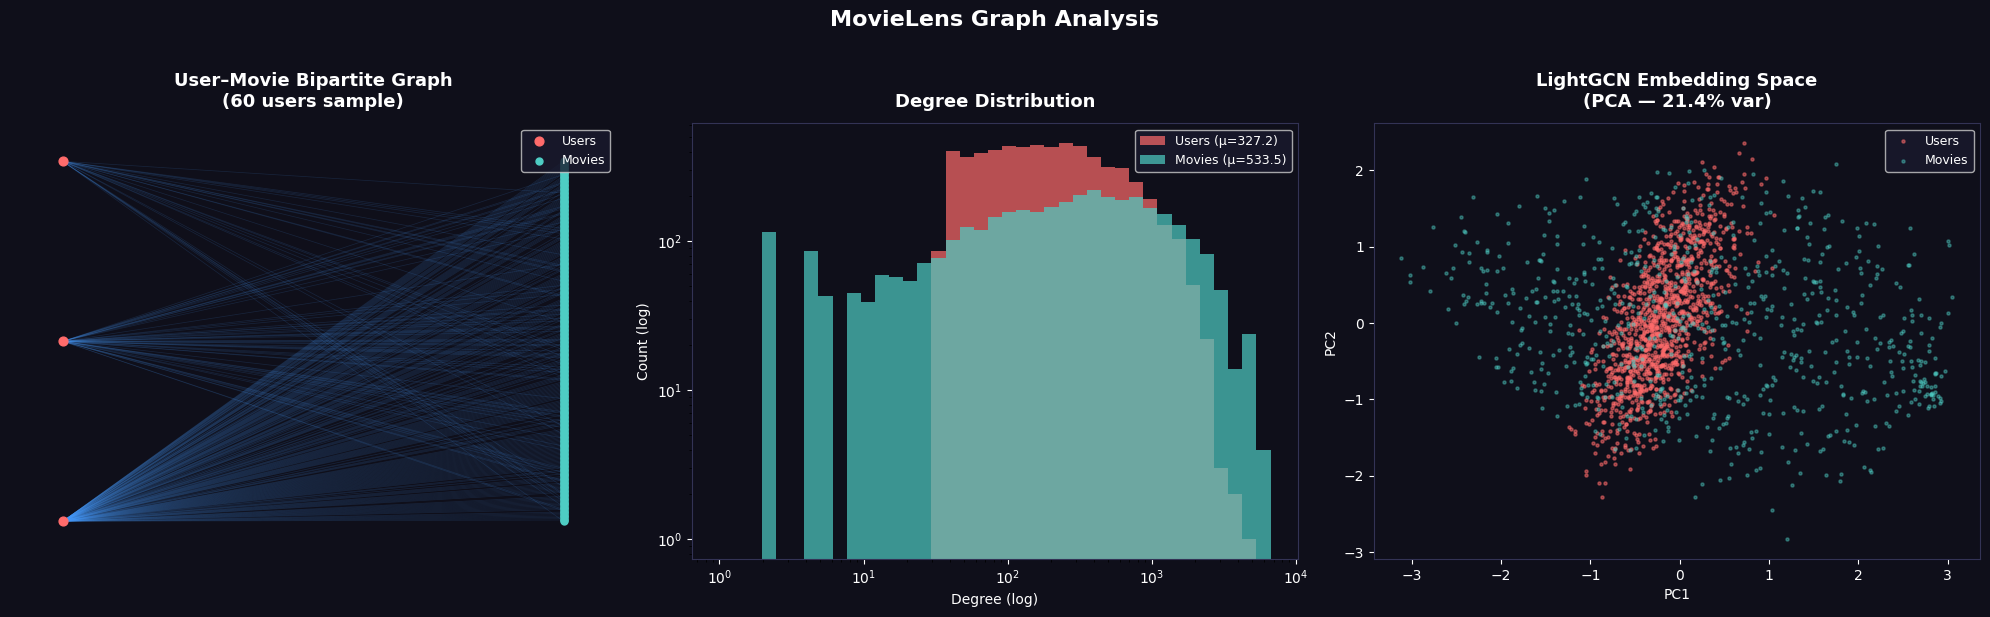

✅ Saved graph_analysis.png


In [22]:
# ═══════════════════════════════════════════════════════════════
#  CELL 2 — Graph Visualization (fixed)
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0f0f1a')
for ax in axes: ax.set_facecolor('#0f0f1a')

ei_cpu = edge_index.cpu().numpy()

# ── Compute degrees from ALL edges (both directions) ─────────────────────────
all_nodes = np.concatenate([ei_cpu[0], ei_cpu[1]])
degree    = np.bincount(all_nodes, minlength=n_users + n_items)
user_degrees = degree[:n_users]
item_degrees = degree[n_users:]

# ── Plot 1: Bipartite subgraph ────────────────────────────────────────────────
ax = axes[0]
# Keep only u→item edges (user nodes < n_users, item nodes >= n_users)
mask        = (ei_cpu[0] < n_users) & (ei_cpu[1] >= n_users)
ei_ui       = ei_cpu[:, mask]
sample_users = np.random.choice(n_users, size=60, replace=False)
sample_set   = set(sample_users.tolist())

G = nx.Graph()
sub_edges = [(ei_ui[0,i], ei_ui[1,i])
             for i in range(ei_ui.shape[1])
             if ei_ui[0,i] in sample_set][:300]

for u, v in sub_edges:
    G.add_node(u, kind='user')
    G.add_node(v, kind='item')
    G.add_edge(u, v)

user_nodes = [n for n,d in G.nodes(data=True) if d.get('kind')=='user']
item_nodes = [n for n,d in G.nodes(data=True) if d.get('kind')=='item']
pos = nx.bipartite_layout(G, user_nodes, align='vertical', scale=2)

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, edge_color='#4a9eff', width=0.5)
nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, ax=ax,
                       node_color='#ff6b6b', node_size=40, label='Users')
nx.draw_networkx_nodes(G, pos, nodelist=item_nodes, ax=ax,
                       node_color='#4ecdc4', node_size=25, label='Movies')
ax.set_title('User–Movie Bipartite Graph\n(60 users sample)', color='white',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper right', facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax.axis('off')

# ── Plot 2: Degree distributions ─────────────────────────────────────────────
ax = axes[1]
max_deg = max(user_degrees.max(), item_degrees.max())
bins    = np.logspace(0, np.log10(max_deg + 1), 40)

ax.hist(user_degrees[user_degrees > 0], bins=bins, alpha=0.7,
        color='#ff6b6b', label=f'Users (μ={user_degrees[user_degrees>0].mean():.1f})')
ax.hist(item_degrees[item_degrees > 0], bins=bins, alpha=0.7,
        color='#4ecdc4', label=f'Movies (μ={item_degrees[item_degrees>0].mean():.1f})')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Degree (log)', color='white')
ax.set_ylabel('Count (log)', color='white')
ax.set_title('Degree Distribution', color='white', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

# ── Plot 3: LightGCN embedding PCA ───────────────────────────────────────────
ax = axes[2]
sample_n = min(2000, n_users + n_items)
idx_samp = np.random.choice(n_users + n_items, sample_n, replace=False)
emb_samp = lgcn_embs[idx_samp].cpu().float().numpy()
pca      = PCA(n_components=2, random_state=42)
coords   = pca.fit_transform(emb_samp)
is_user  = idx_samp < n_users

ax.scatter(coords[ is_user, 0], coords[ is_user, 1],
           c='#ff6b6b', s=5, alpha=0.5, label='Users')
ax.scatter(coords[~is_user, 0], coords[~is_user, 1],
           c='#4ecdc4', s=5, alpha=0.4, label='Movies')
ax.set_title(f'LightGCN Embedding Space\n(PCA — {pca.explained_variance_ratio_.sum():.1%} var)',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('PC1', color='white'); ax.set_ylabel('PC2', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

plt.suptitle('MovieLens Graph Analysis', color='white',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graph_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('✅ Saved graph_analysis.png')

In [23]:
# ═══════════════════════════════════════════════════════════════
#  CELL 3 — LLM Rerankers (HuggingFace)
# ═══════════════════════════════════════════════════════════════
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

# ── Build movie metadata lookup ───────────────────────────────────────────────
# Assumes movies_df with columns: movieId, title, genres  (standard MovieLens)
# Adjust column names if yours differ
try:
    movie_meta = movies_df.set_index('movieId')[['title','genres']].to_dict('index')
except:
    # fallback: build from df_train if movies_df not available
    movie_meta = {}

def get_movie_desc(movie_id):
    if movie_id in movie_meta:
        t = movie_meta[movie_id].get('title', str(movie_id))
        g = movie_meta[movie_id].get('genres', '').replace('|', ', ')
        return f"{t} [{g}]" if g else t
    return f"Movie {movie_id}"

def get_user_profile(user_id, top_n=10):
    """Build a short text profile of a user from their highest-rated movies."""
    user_ratings = df_train[df_train['userId'] == user_id].nlargest(top_n, 'rating')
    titles = [get_movie_desc(mid) for mid in user_ratings['movieId'].tolist()]
    return 'User who enjoyed: ' + '; '.join(titles[:8])

# ── Load reranker models ──────────────────────────────────────────────────────
print('Loading reranker models...\n')

RERANKERS = {}

# 1. Fast cross-encoder (MS-MARCO)
print('  [1/3] cross-encoder/ms-marco-MiniLM-L-6-v2 ...')
RERANKERS['MiniLM CrossEncoder'] = pipeline(
    'text-classification',
    model='cross-encoder/ms-marco-MiniLM-L-6-v2',
    device=0, truncation=True, max_length=512
)

# 2. BGE Reranker (strong general purpose)
print('  [2/3] BAAI/bge-reranker-base ...')
bge_tok = AutoTokenizer.from_pretrained('BAAI/bge-reranker-base')
bge_mdl = AutoModelForSequenceClassification.from_pretrained(
    'BAAI/bge-reranker-base').to(device).eval()
RERANKERS['BGE Reranker'] = (bge_tok, bge_mdl)

# 3. Zero-shot classifier (BART-MNLI) — no training needed
print('  [3/3] facebook/bart-large-mnli ...')
RERANKERS['BART Zero-Shot'] = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=0
)

print('\n✅ All rerankers loaded')

# ── Reranking functions ───────────────────────────────────────────────────────
def rerank_minilm(user_profile, candidates):
    """Cross-encoder: score (user_profile, movie_desc) pairs."""
    pairs = [[user_profile, c] for c in candidates]
    out   = RERANKERS['MiniLM CrossEncoder'](pairs, batch_size=16)
    scores = [o['score'] for o in out]
    return sorted(zip(scores, candidates), reverse=True)

def rerank_bge(user_profile, candidates):
    """BGE reranker: sigmoid score over [CLS]."""
    tok, mdl = RERANKERS['BGE Reranker']
    scores = []
    for cand in candidates:
        enc = tok(user_profile, cand, return_tensors='pt',
                  truncation=True, max_length=512).to(device)
        with torch.no_grad():
            s = torch.sigmoid(mdl(**enc).logits[0]).item()
        scores.append(s)
    return sorted(zip(scores, candidates), reverse=True)

def rerank_bart(user_profile, candidates):
    """BART zero-shot: p('entailment') as relevance score."""
    clf    = RERANKERS['BART Zero-Shot']
    scores = []
    for cand in candidates:
        res = clf(f"{user_profile}", candidate_labels=[cand],
                  hypothesis_template='This user would enjoy {}.')
        scores.append(res['scores'][0])
    return sorted(zip(scores, candidates), reverse=True)

RERANK_FNS = {
    'MiniLM CrossEncoder': rerank_minilm,
    'BGE Reranker':        rerank_bge,
    'BART Zero-Shot':      rerank_bart,
}
print('✅ Reranking functions ready')

Loading reranker models...

  [1/3] cross-encoder/ms-marco-MiniLM-L-6-v2 ...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


✅ All rerankers loaded
✅ Reranking functions ready


In [25]:
# ── Run this first to check your actual column names ─────────────────────────
print(df_train.columns.tolist())
print(df_train.head(2))

['user_id', 'movie_id', 'rating', 'timestamp']
   user_id  movie_id  rating  timestamp
0        1      2355       5  978824291
1        1       919       4  978301368


In [28]:
# ── Load movie titles ─────────────────────────────────────────────────────────
# Option A: if movies.csv is already uploaded somewhere
import pandas as pd, os

# Try common paths
for path in ['/content/movies.csv', '/content/drive/MyDrive/movies.csv',
             'movies.csv', '/content/ml-25m/movies.csv',
             '/content/ml-latest-small/movies.csv']:
    if os.path.exists(path):
        movies_df = pd.read_csv(path)
        print(f'✅ Loaded movies_df from {path}: {movies_df.shape}')
        print(movies_df.head(3))
        break
else:
    print('❌ movies.csv not found — downloading MovieLens...')
    import urllib.request, zipfile
    urllib.request.urlretrieve(
        'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip',
        '/content/ml-latest-small.zip'
    )
    with zipfile.ZipFile('/content/ml-latest-small.zip') as z:
        z.extractall('/content/')
    movies_df = pd.read_csv('/content/ml-latest-small/movies.csv')
    print(f'✅ Downloaded and loaded movies_df: {movies_df.shape}')
    print(movies_df.head(3))

❌ movies.csv not found — downloading MovieLens...
✅ Downloaded and loaded movies_df: (9742, 3)
   movieId                    title  \
0        1         Toy Story (1995)   
1        2           Jumanji (1995)   
2        3  Grumpier Old Men (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  


In [29]:
# ── Patch get_movie_desc once movies_df is loaded ─────────────────────────────
MOVIE_ID_COL    = 'movieId'    # adjust if different
MOVIE_TITLE_COL = 'title'
MOVIE_GENRE_COL = 'genres'

_movie_lookup = movies_df.set_index(MOVIE_ID_COL).to_dict('index')

def get_movie_desc(movie_id):
    row = _movie_lookup.get(movie_id)
    if row:
        title  = row.get(MOVIE_TITLE_COL, f'Movie {movie_id}')
        genres = str(row.get(MOVIE_GENRE_COL, '')).replace('|', ', ')
        return f"{title} [{genres}]" if genres and genres != 'nan' else title
    return f"Movie {movie_id}"

# Quick test
print(get_movie_desc(1))    # should print "Toy Story (1995) [Adventure, Animation, ...]"
print(get_movie_desc(260))  # Star Wars

Toy Story (1995) [Adventure, Animation, Children, Comedy, Fantasy]
Star Wars: Episode IV - A New Hope (1977) [Action, Adventure, Sci-Fi]


In [30]:
# ═══════════════════════════════════════════════════════════════
#  CELL 4 — Interactive Demo (fixed column names)
# ═══════════════════════════════════════════════════════════════
from IPython.display import HTML, display
import random, torch

# ── Auto-detect column names ──────────────────────────────────────────────────
_cols = df_train.columns.tolist()
USER_COL = next(c for c in _cols if 'user' in c.lower())
ITEM_COL = next(c for c in _cols if 'movie' in c.lower() or 'item' in c.lower())
RATE_COL = next((c for c in _cols if 'rating' in c.lower()), None)
print(f'Detected columns → user: {USER_COL!r}  item: {ITEM_COL!r}  rating: {RATE_COL!r}')

# ── Build idx2user if missing ─────────────────────────────────────────────────
if 'idx2user' not in dir():
    idx2user = {v: k for k, v in user2idx.items()}
if 'idx2item' not in dir():
    idx2item = {v: k for k, v in item2idx.items()}

CANDIDATE_K = 20
DISPLAY_TOP = 10

def get_movie_desc(movie_id):
    try:
        row = movies_df[movies_df['movieId'] == movie_id].iloc[0]
        g   = str(row.get('genres', '')).replace('|', ', ')
        return f"{row['title']} [{g}]" if g else str(row['title'])
    except:
        return f"Movie {movie_id}"

def get_user_profile(user_id, top_n=8):
    rows = df_train[df_train[USER_COL] == user_id]
    if RATE_COL:
        rows = rows.nlargest(top_n, RATE_COL)
    else:
        rows = rows.head(top_n)
    titles = [get_movie_desc(m) for m in rows[ITEM_COL].tolist()]
    return 'User who enjoyed: ' + '; '.join(titles)

def get_recommendations(user_node_idx, embs, k=CANDIDATE_K):
    with torch.no_grad():
        u_emb  = embs[user_node_idx].unsqueeze(0)
        i_embs = embs[item_idx_tensor]
        scores = (u_emb @ i_embs.T).squeeze(0)
        uid    = idx2user.get(user_node_idx, -1)
        seen   = set(df_train[df_train[USER_COL] == uid][ITEM_COL].tolist())
        seen_nodes = {item2idx[m] for m in seen if m in item2idx}
        seen_pos   = [i for i, n in enumerate(item_idx_tensor.tolist()) if n in seen_nodes]
        scores[seen_pos] = -9999.0
        top_idx = scores.topk(k).indices.cpu().tolist()
    return [item_idx_tensor[i].item() for i in top_idx]

def demo_user(user_id=None, reranker_name='BGE Reranker'):
    if user_id is None:
        active  = df_train.groupby(USER_COL).size()
        user_id = int(active[active >= 20].sample(1).index[0])

    user_node = user2idx.get(user_id)
    if user_node is None:
        print(f'User {user_id} not in user2idx'); return

    user_profile = get_user_profile(user_id)
    print(f'\n{"═"*70}')
    print(f'  👤  User {user_id}')
    print(f'  📝  {user_profile[:120]}')
    print(f'{"═"*70}\n')

    rows = []
    inv_item = {v: k for k, v in item2idx.items()}

    for model_name, embs in all_model_embs.items():
        cand_nodes  = get_recommendations(user_node, embs, k=CANDIDATE_K)
        cand_mids   = [inv_item.get(n, n) for n in cand_nodes]
        cand_descs  = [get_movie_desc(m) for m in cand_mids]

        try:
            reranked       = RERANK_FNS[reranker_name](user_profile, cand_descs)
            reranked_descs = [d for _, d in reranked[:DISPLAY_TOP]]
        except Exception as e:
            print(f'  Reranker error: {e}')
            reranked_descs = cand_descs[:DISPLAY_TOP]

        rows.append((model_name, cand_descs[:DISPLAY_TOP], reranked_descs))

    html = f"""
    <style>
      .demo-wrap {{ font-family:'Courier New',monospace; background:#0f0f1a;
                   color:#e0e0ff; padding:20px; border-radius:12px; }}
      .demo-wrap h2 {{ color:#7eb8f7; border-bottom:1px solid #333; padding-bottom:8px; }}
      .model-block {{ margin:16px 0; background:#1a1a2e; border-radius:8px;
                      padding:14px; border-left:4px solid #4a9eff; }}
      .model-title {{ font-size:14px; font-weight:bold; color:#4ecdc4;
                      margin-bottom:10px; letter-spacing:1px; }}
      .rec-grid {{ display:grid; grid-template-columns:1fr 1fr; gap:12px; }}
      .rec-col h4 {{ color:#aaa; font-size:11px; text-transform:uppercase;
                     letter-spacing:2px; margin:0 0 8px 0; }}
      .rec-item {{ font-size:12px; padding:4px 8px; border-radius:4px;
                   background:#0d0d1f; margin:3px 0; }}
      .rank {{ color:#888; margin-right:8px; }}
      .better {{ background:#0d2b0d !important; border-left:2px solid #4ecdc4; }}
    </style>
    <div class="demo-wrap">
      <h2>🎬 Movie Recommendations — User {user_id}</h2>
      <p style="color:#888;font-size:12px">{user_profile[:140]}</p>
      <p style="color:#666;font-size:11px">Reranker: <b style="color:#f0a500">{reranker_name}</b>
         | top-{CANDIDATE_K} → reranked to top-{DISPLAY_TOP}</p>
    """
    for model_name, before, after in rows:
        html += f"""
      <div class="model-block">
        <div class="model-title">⚡ {model_name}</div>
        <div class="rec-grid">
          <div class="rec-col">
            <h4>Before LLM Reranking</h4>
            {''.join(f'<div class="rec-item"><span class="rank">#{i+1}</span>{d[:60]}</div>'
                     for i,d in enumerate(before))}
          </div>
          <div class="rec-col">
            <h4>After {reranker_name}</h4>
            {''.join(f'<div class="rec-item better"><span class="rank">#{i+1}</span>{d[:60]}</div>'
                     for i,d in enumerate(after))}
          </div>
        </div>
      </div>"""
    html += '</div>'
    display(HTML(html))

# ── Run ───────────────────────────────────────────────────────────────────────
for rname in ['BGE Reranker', 'MiniLM CrossEncoder', 'BART Zero-Shot']:
    print(f'\nRunning demo with {rname}...')
    demo_user(reranker_name=rname)

Detected columns → user: 'user_id'  item: 'movie_id'  rating: 'rating'

Running demo with BGE Reranker...

══════════════════════════════════════════════════════════════════════
  👤  User 5089
  📝  User who enjoyed: Election (1999) [Comedy]; Citizen Kane (1941) [Drama, Mystery]; Run Lola Run (Lola rennt) (1998) [Acti
══════════════════════════════════════════════════════════════════════




Running demo with MiniLM CrossEncoder...

══════════════════════════════════════════════════════════════════════
  👤  User 4253
  📝  User who enjoyed: Annie Hall (1977) [Comedy, Romance]; Wizard of Oz, The (1939) [Adventure, Children, Fantasy, Musical];
══════════════════════════════════════════════════════════════════════

  Reranker error: The pipeline received invalid inputs, if you are trying to send text pairs, you can try to send a dictionary `{"text": "My text", "text_pair": "My pair"}` in order to send a text pair.



Running demo with BART Zero-Shot...

══════════════════════════════════════════════════════════════════════
  👤  User 2033
  📝  User who enjoyed: My Dog Skip (1999) [Children, Drama]; Me, Myself & Irene (2000) [Adventure, Comedy]; Tao of Steve, The
══════════════════════════════════════════════════════════════════════



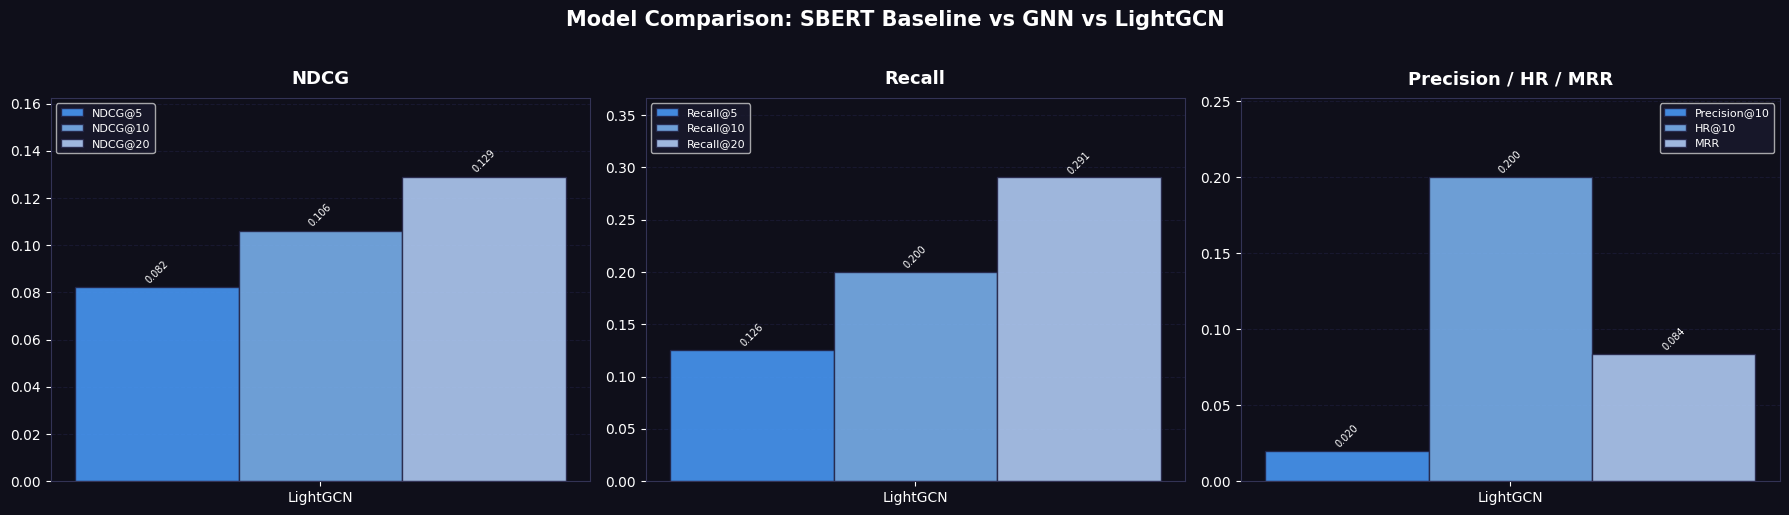

✅ Saved model_comparison.png


In [27]:
# ═══════════════════════════════════════════════════════════════
#  CELL 5 — Summary bar chart (all models, all metrics)
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')
for ax in axes: ax.set_facecolor('#0f0f1a')

models  = list(df_eval.columns)
colors  = ['#888888', '#4ecdc4', '#ff6b6b']
x       = np.arange(len(models))

for ax_i, (ax, metric_group, title) in enumerate(zip(
    axes,
    [['NDCG@5','NDCG@10','NDCG@20'],
     ['Recall@5','Recall@10','Recall@20'],
     ['Precision@10','HR@10','MRR']],
    ['NDCG', 'Recall', 'Precision / HR / MRR']
)):
    width  = 0.22
    sub_colors = ['#4a9eff','#7eb8f7','#b8d4ff']
    for j, metric in enumerate(metric_group):
        vals = [df_eval.loc[metric, m] for m in models]
        bars = ax.bar(x + j*width, vals, width, label=metric,
                      color=sub_colors[j], alpha=0.85, edgecolor='#222244')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                    f'{v:.3f}', ha='center', va='bottom',
                    color='white', fontsize=7, rotation=45)

    ax.set_xticks(x + width)
    ax.set_xticklabels(models, color='white', fontsize=10)
    ax.tick_params(colors='white')
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=10)
    ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
    for spine in ax.spines.values(): spine.set_edgecolor('#333355')
    ax.yaxis.grid(True, color='#222244', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.suptitle('Model Comparison: SBERT Baseline vs GNN vs LightGCN',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('✅ Saved model_comparison.png')

In [33]:
!pip install faiss-cpu sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 93.6 MB/s eta 0:00:00


In [36]:
import subprocess

# If conda isn't available, fall back to CPU version
!pip install faiss-cpu sentence-transformers -q

In [38]:
# ── Replace the generator block only (lines 44-47) ───────────────────────────
from transformers import T5ForConditionalGeneration, AutoTokenizer

print('\nLoading Flan-T5-large...')
t5_tok = AutoTokenizer.from_pretrained('google/flan-t5-large')
t5_mdl = T5ForConditionalGeneration.from_pretrained(
    'google/flan-t5-large', torch_dtype=torch.float16).to(device)
t5_mdl.eval()
print('✅ RAG pipeline ready\n')

def _generate(prompt, max_new_tokens=300):
    ids = t5_tok(prompt, return_tensors='pt',
                 max_length=512, truncation=True).input_ids.to(device)
    with torch.no_grad():
        out = t5_mdl.generate(ids, max_new_tokens=max_new_tokens,
                               num_beams=4, early_stopping=True)
    return t5_tok.decode(out[0], skip_special_tokens=True)

# ── Updated rag_recommend (only generator call changes) ──────────────────────
def rag_recommend(query_text, user_id=None, top_k_text=12, top_k_cf=10, final_n=5):
    q_vec = sbert.encode([query_text], normalize_embeddings=True).astype('float32')
    _, text_ids = faiss_index.search(q_vec, top_k_text)
    text_movies = [(all_movie_ids[i], all_movie_descs[i]) for i in text_ids[0]]

    cf_movies = []
    if user_id is not None and user_id in user2idx:
        u_node = user2idx[user_id]
        u_emb  = lgcn_all[u_node].cpu().float().numpy()
        u_emb  = u_emb / (np.linalg.norm(u_emb) + 1e-9)
        _, cf_ids = lgcn_faiss.search(u_emb.reshape(1,-1), top_k_cf)
        seen = set(df_train[df_train[USER_COL]==user_id][ITEM_COL].tolist())
        for pos in cf_ids[0]:
            mid = item_pos_to_mid[pos]
            if mid not in seen:
                cf_movies.append((mid, get_movie_desc(mid)))

    seen_ids, merged = set(), []
    for mid, desc in text_movies + cf_movies:
        if mid not in seen_ids:
            seen_ids.add(mid); merged.append((mid, desc))

    user_ctx = ''
    if user_id is not None:
        user_ctx = f"User history: {get_user_profile(user_id, top_n=5)}\n"

    candidates_txt = '\n'.join(f'- {desc}' for _, desc in merged[:15])
    prompt = f"""You are a movie recommendation expert.
{user_ctx}User request: "{query_text}"

Candidate movies:
{candidates_txt}

From the candidates, recommend the top {final_n} most suitable movies for this request.
For each, give the title and one sentence explaining why it fits."""

    out = _generate(prompt)
    return out, text_movies, cf_movies, merged


Loading Flan-T5-large...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ RAG pipeline ready



In [39]:
# ═══════════════════════════════════════════════════════════════
#  RAG CELL B — 3 Example Queries
# ═══════════════════════════════════════════════════════════════

QUERIES = [
    {
        'query':   'I want a mind-bending psychological thriller that keeps me guessing',
        'user_id': None,
        'color':   '#e74c3c',
        'icon':    '🧠',
    },
    {
        'query':   'Feel-good romantic comedies from the 90s with great chemistry',
        'user_id': None,
        'color':   '#e67e22',
        'icon':    '💕',
    },
    {
        'query':   'Epic sci-fi with stunning visuals and a deep philosophical story',
        'user_id': None,
        'color':   '#2980b9',
        'icon':    '🚀',
    },
]

results = []
for q in QUERIES:
    print(f"\n{q['icon']} Query: \"{q['query']}\"")
    out, text_cands, cf_cands, merged = rag_recommend(
        q['query'], user_id=q['user_id'], top_k_text=12, final_n=5)
    results.append({**q, 'output': out,
                    'text_cands': text_cands,
                    'cf_cands':   cf_cands,
                    'merged':     merged})
    print(out)
    print('─'*60)

# ── Render as HTML cards ──────────────────────────────────────────────────────
html = """
<style>
  .rag-wrap { font-family: 'Georgia', serif; background: #0a0a14;
              color: #dde; padding: 24px; border-radius: 14px; }
  .rag-query { font-size:13px; color:#aaa; margin-bottom:6px;
               text-transform:uppercase; letter-spacing:2px; }
  .rag-card  { margin:20px 0; padding:18px; border-radius:10px;
               background:#12121f; }
  .rag-card h3 { margin:0 0 10px; font-size:16px; }
  .rag-cands { display:flex; gap:8px; flex-wrap:wrap; margin:10px 0; }
  .cand-pill { font-size:11px; padding:3px 10px; border-radius:20px;
               background:#1e1e35; color:#ccd; border:1px solid #333; }
  .cand-pill.text { border-color:#e74c3c44; background:#1a0d0d; }
  .cand-pill.cf   { border-color:#2980b944; background:#0d141a; }
  .rag-output { font-size:13px; line-height:1.8; color:#e8e8f8;
                background:#0d0d1e; padding:14px; border-radius:8px;
                border-left:3px solid; white-space:pre-wrap; }
  .legend { font-size:11px; color:#666; margin-top:8px; }
  .dot { display:inline-block; width:8px; height:8px;
         border-radius:50%; margin-right:4px; }
</style>
<div class="rag-wrap">
  <h2 style="color:#7eb8f7;border-bottom:1px solid #222;padding-bottom:10px">
    🔍 RAG Movie Recommendations</h2>
"""

for r in results:
    text_titles = [d[:40] for _, d in r['text_cands'][:6]]
    cf_titles   = [d[:40] for _, d in r['cf_cands'][:4]]

    text_pills = ''.join(f'<span class="cand-pill text">{t}</span>' for t in text_titles)
    cf_pills   = ''.join(f'<span class="cand-pill cf">{t}</span>'   for t in cf_titles)

    html += f"""
  <div class="rag-card">
    <div class="rag-query">{r['icon']} User Query</div>
    <h3 style="color:{r['color']}">&ldquo;{r['query']}&rdquo;</h3>

    <div class="rag-query" style="margin-top:12px">📄 Text Retrieved ({len(r['text_cands'])})</div>
    <div class="rag-cands">{text_pills}</div>

    <div class="rag-query" style="margin-top:8px">🤖 Generated Recommendations</div>
    <div class="rag-output" style="border-color:{r['color']}">{r['output']}</div>

    <div class="legend">
      <span class="dot" style="background:#e74c3c"></span>Text retrieval
      <span class="dot" style="background:#2980b9;margin-left:12px"></span>CF retrieval
      &nbsp;· {len(r['merged'])} total candidates → Flan-T5-large
    </div>
  </div>"""

html += '</div>'
display(HTML(html))


🧠 Query: "I want a mind-bending psychological thriller that keeps me guessing"
Paradox (2010) [Sci-Fi, Thriller] The Great Hypnotist (2014) [Drama, Mystery, Thriller] Knowing (2009) [Sci-Fi, Thriller]
────────────────────────────────────────────────────────────

💕 Query: "Feel-good romantic comedies from the 90s with great chemistry"
Singles (1992) [Comedy, Romance] Maybe Baby (2000) [Comedy, Romance] Love and Other Drugs (2010) [Comedy, Drama, Romance] Seems Like Old Times
────────────────────────────────────────────────────────────

🚀 Query: "Epic sci-fi with stunning visuals and a deep philosophical story"
Transcendence is an epic sci-fi with stunning visuals and a deep philosophical story
────────────────────────────────────────────────────────────


In [40]:
# ═══════════════════════════════════════════════════════════════
#  LLM EXPLANATIONS — Why was each movie recommended?
# ═══════════════════════════════════════════════════════════════
from IPython.display import display, HTML
import torch

def explain_recommendations(user_id, top_n=5):
    """
    For a given user:
    1. Get their top-N LightGCN recommendations
    2. Build their taste profile from watch history
    3. For each recommended movie, generate a personalized explanation
    """
    user_node = user2idx.get(user_id)
    if user_node is None:
        print(f'User {user_id} not found'); return

    # ── Get top-N recs ────────────────────────────────────────────────────────
    inv_item = {v: k for k, v in item2idx.items()}
    with torch.no_grad():
        u_emb  = lgcn_all[user_node].unsqueeze(0)
        i_embs = lgcn_all[item_idx_tensor]
        scores = (u_emb @ i_embs.T).squeeze(0)
        seen   = set(df_train[df_train[USER_COL]==user_id][ITEM_COL].tolist())
        seen_pos = [i for i,n in enumerate(item_idx_tensor.tolist())
                    if inv_item.get(n) in seen]
        scores[seen_pos] = -9999.0
        top_idx = scores.topk(top_n).indices.cpu().tolist()

    rec_movies = [(inv_item[item_idx_tensor[i].item()],
                   get_movie_desc(inv_item[item_idx_tensor[i].item()]))
                  for i in top_idx]

    # ── Build user taste profile ──────────────────────────────────────────────
    user_history = df_train[df_train[USER_COL] == user_id]
    if RATE_COL:
        top_rated = user_history.nlargest(6, RATE_COL)
    else:
        top_rated = user_history.head(6)
    liked_titles = [get_movie_desc(m) for m in top_rated[ITEM_COL].tolist()]
    profile_str  = '; '.join(liked_titles)

    # ── Generate explanation for each movie ───────────────────────────────────
    print(f'Generating explanations for User {user_id}...')
    explanations = []
    for mid, desc in rec_movies:
        prompt = f"""A user has watched and enjoyed these movies: {profile_str}.

The recommendation system suggested: "{desc}"

In 2-3 sentences, explain specifically why this movie is a great match for this user based on their taste. Be concrete about genre, themes, or style similarities."""

        explanation = _generate(prompt, max_new_tokens=120)
        explanations.append((desc, explanation))
        print(f'  ✓ {desc[:50]}')

    # ── Render HTML ───────────────────────────────────────────────────────────
    html = f"""
    <style>
      .exp-wrap {{ font-family: Georgia, serif; background: #09090f;
                  color: #dde; padding: 24px; border-radius: 14px; max-width:900px; }}
      .exp-wrap h2 {{ color: #7eb8f7; border-bottom: 1px solid #1e1e3a;
                      padding-bottom: 10px; font-size: 18px; }}
      .profile-box {{ background: #111125; border-radius: 8px; padding: 12px 16px;
                      margin-bottom: 20px; border-left: 3px solid #f39c12; }}
      .profile-box p {{ margin:0; font-size:12px; color:#bbb; line-height:1.7; }}
      .profile-label {{ font-size:10px; text-transform:uppercase; letter-spacing:2px;
                        color:#f39c12; margin-bottom:6px; font-weight:bold; }}
      .exp-card {{ display:flex; gap:16px; align-items:flex-start;
                   background:#111125; border-radius:10px; padding:16px;
                   margin:12px 0; border-left:3px solid #4a9eff; }}
      .rank-badge {{ background:#4a9eff; color:#000; font-weight:bold;
                     border-radius:50%; width:28px; height:28px; min-width:28px;
                     display:flex; align-items:center; justify-content:center;
                     font-size:13px; }}
      .exp-content {{ flex:1; }}
      .movie-title {{ font-size:14px; font-weight:bold; color:#e8e8ff;
                      margin-bottom:6px; }}
      .movie-genre {{ font-size:11px; color:#7eb8f7; margin-bottom:8px; }}
      .exp-text {{ font-size:13px; color:#c8c8e8; line-height:1.7;
                   font-style:italic; }}
      .exp-label {{ font-size:10px; text-transform:uppercase; letter-spacing:2px;
                    color:#27ae60; margin-bottom:4px; }}
    </style>
    <div class="exp-wrap">
      <h2>🎬 Personalized Recommendations — User {user_id}</h2>

      <div class="profile-box">
        <div class="profile-label">👤 User Taste Profile</div>
        <p>{profile_str}</p>
      </div>
    """

    for i, (desc, expl) in enumerate(explanations):
        # split title from genre
        parts  = desc.split('[')
        title  = parts[0].strip()
        genres = f'[{parts[1]}' if len(parts) > 1 else ''
        html += f"""
      <div class="exp-card">
        <div class="rank-badge">#{i+1}</div>
        <div class="exp-content">
          <div class="movie-title">{title}</div>
          <div class="movie-genre">{genres}</div>
          <div class="exp-label">💡 Why this movie?</div>
          <div class="exp-text">{expl}</div>
        </div>
      </div>"""

    html += '</div>'
    display(HTML(html))

# ── Run for 2 different users ─────────────────────────────────────────────────
active_users = df_train.groupby(USER_COL).size()
user_sample  = active_users[active_users >= 20].sample(2).index.tolist()

for uid in user_sample:
    explain_recommendations(uid, top_n=5)
    print()

Generating explanations for User 1145...
  ✓ Amityville Horror, The (1979) [Drama, Horror, Myst
  ✓ Braveheart (1995) [Action, Drama, War]
  ✓ One Flew Over the Cuckoo's Nest (1975) [Drama]
  ✓ Fly, The (1986) [Drama, Horror, Sci-Fi, Thriller]
  ✓ Fly, The (1958) [Horror, Mystery, Sci-Fi]



Generating explanations for User 804...
  ✓ Pulp Fiction (1994) [Comedy, Crime, Drama, Thrille
  ✓ L.A. Confidential (1997) [Crime, Film-Noir, Myster
  ✓ American Beauty (1999) [Drama, Romance]
  ✓ Being John Malkovich (1999) [Comedy, Drama, Fantas
  ✓ Usual Suspects, The (1995) [Crime, Mystery, Thrill


Running 5 queries through RAG pipeline...

  🧠  Mind-bending psychological thriller that keeps me on edge...
     → 3 recommendations generated
  😂  Heartwarming feel-good comedy with great friendships...
     → 3 recommendations generated
  🚀  Epic space sci-fi with deep philosophical themes...
     → 3 recommendations generated
  🕵️  Classic crime drama with complex morally grey characters...
     → 3 recommendations generated
  💌  Romantic drama set in a beautiful historical period...
     → 3 recommendations generated

✅ All queries complete



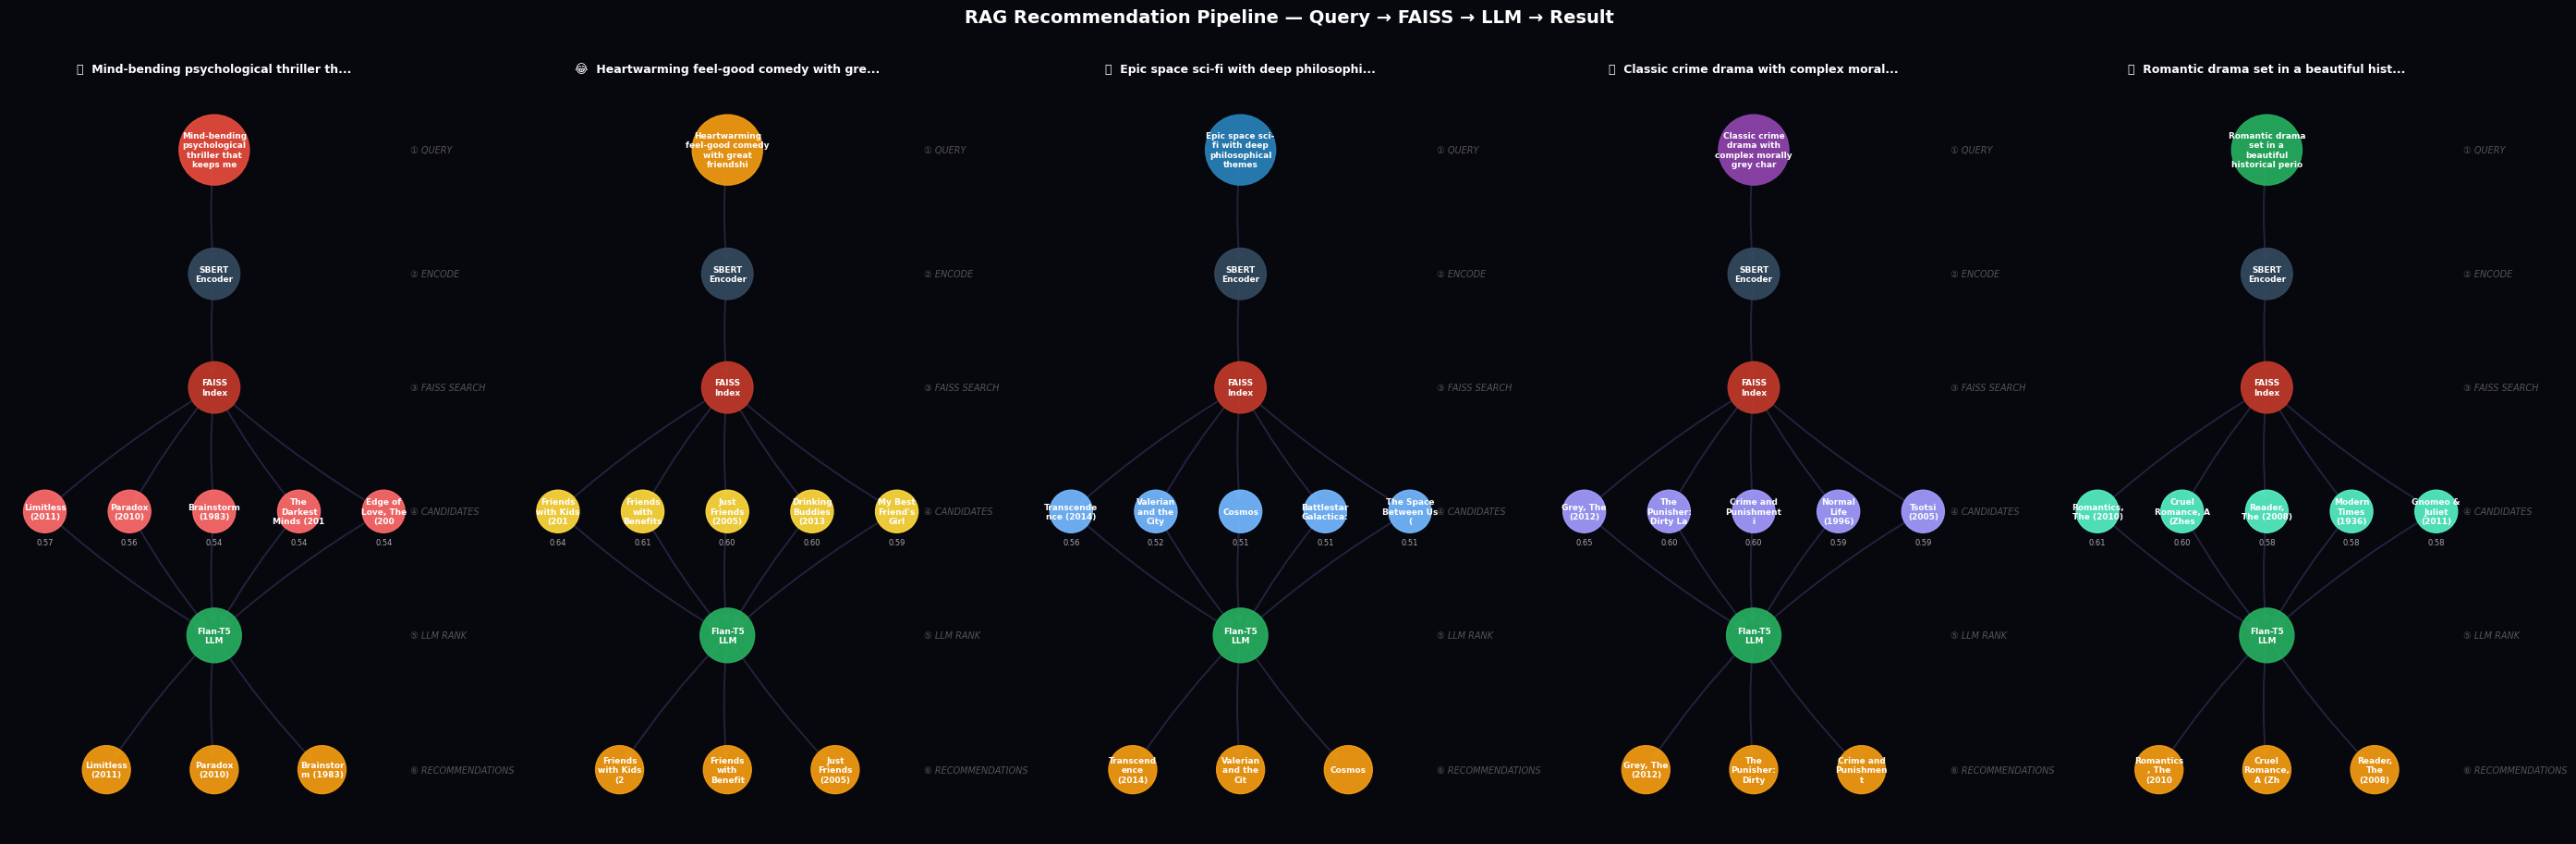

✅ Saved rag_paths.png


In [41]:
# ═══════════════════════════════════════════════════════════════
#  FULL RAG DEMO — Query → Retrieval Path → Recs → LLM Why
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
import networkx as nx
import textwrap, torch, numpy as np
from IPython.display import display, HTML

QUERIES = [
    {
        'query':  'Mind-bending psychological thriller that keeps me on edge',
        'icon':   '🧠', 'color': '#e74c3c', 'accent': '#ff6b6b',
    },
    {
        'query':  'Heartwarming feel-good comedy with great friendships',
        'icon':   '😂', 'color': '#f39c12', 'accent': '#ffd93d',
    },
    {
        'query':  'Epic space sci-fi with deep philosophical themes',
        'icon':   '🚀', 'color': '#2980b9', 'accent': '#74b9ff',
    },
    {
        'query':  'Classic crime drama with complex morally grey characters',
        'icon':   '🕵️', 'color': '#8e44ad', 'accent': '#a29bfe',
    },
    {
        'query':  'Romantic drama set in a beautiful historical period',
        'icon':   '💌', 'color': '#27ae60', 'accent': '#55efc4',
    },
]

# ─────────────────────────────────────────────────────────────────────────────
#  Step 1 — Run retrieval + LLM explanation for all queries
# ─────────────────────────────────────────────────────────────────────────────
def run_query(q, top_k=8, final_n=3):
    # Text retrieval via FAISS
    q_vec = sbert.encode([q['query']], normalize_embeddings=True).astype('float32')
    _, text_ids = faiss_index.search(q_vec, top_k)
    text_hits   = [(all_movie_ids[i], all_movie_descs[i],
                    float(np.dot(q_vec[0], movie_vecs[i])))
                   for i in text_ids[0]]

    # Build candidates string
    cand_str = '\n'.join(f'- {d}' for _, d, _ in text_hits[:12])

    # LLM: pick best + explain each
    prompt = f"""You are a movie expert. A user asks: "{q['query']}"

Candidate movies retrieved:
{cand_str}

Pick the {final_n} best matches. For each write:
TITLE: <exact title>
WHY: <one vivid sentence why it perfectly fits the request>

Be specific about genre, mood, and themes."""

    raw   = _generate(prompt, max_new_tokens=250)
    recs  = parse_llm_output(raw, text_hits, final_n)
    return text_hits, recs

def parse_llm_output(raw, text_hits, n):
    """Extract (title, why) pairs; fall back to top hits if parsing fails."""
    lines = raw.strip().split('\n')
    recs, cur_title, cur_why = [], None, None
    for line in lines:
        line = line.strip()
        if line.upper().startswith('TITLE:'):
            cur_title = line.split(':', 1)[1].strip()
        elif line.upper().startswith('WHY:'):
            cur_why = line.split(':', 1)[1].strip()
            if cur_title:
                recs.append((cur_title, cur_why))
                cur_title = cur_why = None
    # fallback
    if not recs:
        for _, desc, _ in text_hits[:n]:
            title = desc.split('[')[0].strip()
            recs.append((title, 'Highly relevant based on semantic similarity.'))
    return recs[:n]

print('Running 5 queries through RAG pipeline...\n')
all_results = []
for q in QUERIES:
    print(f"  {q['icon']}  {q['query'][:60]}...")
    hits, recs = run_query(q, top_k=10, final_n=3)
    all_results.append({'q': q, 'hits': hits, 'recs': recs})
    print(f"     → {len(recs)} recommendations generated")
print('\n✅ All queries complete\n')

# ─────────────────────────────────────────────────────────────────────────────
#  Step 2 — Graph path visualisation (one figure per query)
# ─────────────────────────────────────────────────────────────────────────────
def draw_pipeline_graph(ax, q_text, hits, recs, color, accent):
    ax.set_facecolor('#07070e')
    ax.axis('off')

    G   = nx.DiGraph()
    pos = {}; nc = {}; ns = {}; nl = {}

    # Query node
    G.add_node('Q'); pos['Q'] = (0, 3.6)
    nc['Q'] = color; ns['Q'] = 3000
    nl['Q'] = '\n'.join(textwrap.wrap(q_text[:50], 16))

    # SBERT encoder node
    G.add_node('ENC'); pos['ENC'] = (0, 2.4)
    nc['ENC'] = '#34495e'; ns['ENC'] = 1600
    nl['ENC'] = 'SBERT\nEncoder'
    G.add_edge('Q', 'ENC')

    # FAISS index node
    G.add_node('IDX'); pos['IDX'] = (0, 1.3)
    nc['IDX'] = '#c0392b'; ns['IDX'] = 1600
    nl['IDX'] = 'FAISS\nIndex'
    G.add_edge('ENC', 'IDX')

    # Top retrieved movie nodes (show top 5)
    shown_hits = hits[:5]
    n_hits     = len(shown_hits)
    xs         = np.linspace(-2.2, 2.2, n_hits)
    for i, (mid, desc, score) in enumerate(shown_hits):
        nid = f'H{i}'
        G.add_node(nid); pos[nid] = (xs[i], 0.1)
        nc[nid] = accent + 'cc'
        ns[nid] = 1100
        title   = desc.split('[')[0].strip()
        nl[nid] = '\n'.join(textwrap.wrap(title[:22], 10))
        G.add_edge('IDX', nid)

    # LLM node
    G.add_node('LLM'); pos['LLM'] = (0, -1.1)
    nc['LLM'] = '#27ae60'; ns['LLM'] = 1800
    nl['LLM'] = 'Flan-T5\nLLM'
    for i in range(n_hits):
        G.add_edge(f'H{i}', 'LLM')

    # Final recommendation nodes
    n_recs = len(recs)
    xs_rec = np.linspace(-1.4, 1.4, n_recs)
    for i, (title, why) in enumerate(recs):
        nid = f'R{i}'
        G.add_node(nid); pos[nid] = (xs_rec[i], -2.4)
        nc[nid] = '#f39c12'; ns[nid] = 1400
        nl[nid] = '\n'.join(textwrap.wrap(title[:20], 9))
        G.add_edge('LLM', nid)

    node_list  = list(G.nodes())
    color_list = [nc[n] for n in node_list]
    size_list  = [ns[n] for n in node_list]
    label_dict = {n: nl[n] for n in node_list}

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#2a2a4a',
                           arrows=True, arrowsize=14, width=1.4,
                           alpha=0.8, connectionstyle='arc3,rad=0.05')
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=node_list,
                           node_color=color_list, node_size=size_list, alpha=0.93)
    nx.draw_networkx_labels(G, pos, labels=label_dict, ax=ax,
                            font_size=6.5, font_color='white', font_weight='bold')

    # Score annotations on retrieval edges
    for i, (_, _, score) in enumerate(shown_hits):
        mx, my = pos[f'H{i}']
        ax.text(mx, my - 0.32, f'{score:.2f}', ha='center',
                fontsize=6, color='#aaa')

    # Stage labels
    for label, y in [('① QUERY', 3.6), ('② ENCODE', 2.4),
                     ('③ FAISS SEARCH', 1.3), ('④ CANDIDATES', 0.1),
                     ('⑤ LLM RANK', -1.1), ('⑥ RECOMMENDATIONS', -2.4)]:
        ax.text(2.55, y, label, va='center', ha='left',
                fontsize=7, color='#555', style='italic')


fig, axes = plt.subplots(1, 5, figsize=(28, 9))
fig.patch.set_facecolor('#07070e')

for ax, res in zip(axes, all_results):
    draw_pipeline_graph(ax, res['q']['query'], res['hits'],
                        res['recs'], res['q']['color'], res['q']['accent'])
    ax.set_title(f"{res['q']['icon']}  {res['q']['query'][:38]}...",
                 color='white', fontsize=9, fontweight='bold', pad=10)

plt.suptitle('RAG Recommendation Pipeline — Query → FAISS → LLM → Result',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(w_pad=0.5)
plt.savefig('rag_paths.png', dpi=150, bbox_inches='tight', facecolor='#07070e')
plt.show()
print('✅ Saved rag_paths.png')

# ─────────────────────────────────────────────────────────────────────────────
#  Step 3 — HTML cards: query + recs + LLM why
# ─────────────────────────────────────────────────────────────────────────────
html = """
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700&family=Source+Sans+3:ital,wght@0,400;0,600;1,400&display=swap" rel="stylesheet">
<style>
  .rag-root { background:#07070e; padding:28px 20px; border-radius:16px;
              font-family:'Source Sans 3',sans-serif; color:#dde; }
  .rag-root h1 { font-family:'Playfair Display',serif; font-size:22px;
                 color:#f5f5ff; border-bottom:1px solid #1a1a2e;
                 padding-bottom:12px; margin-bottom:24px; letter-spacing:.5px; }
  .q-block  { margin-bottom:32px; }
  .q-header { display:flex; align-items:center; gap:12px; margin-bottom:14px; }
  .q-icon   { font-size:22px; }
  .q-text   { font-family:'Playfair Display',serif; font-size:16px; color:#f0f0ff; }
  .q-meta   { font-size:11px; color:#666; margin-top:2px; letter-spacing:1px;
               text-transform:uppercase; }
  .hits-row { display:flex; flex-wrap:wrap; gap:6px; margin-bottom:14px; }
  .hit-pill { font-size:11px; padding:3px 11px; border-radius:20px;
              background:#11112a; border:1px solid #2a2a50; color:#99aacc; }
  .hit-score{ color:#556; font-size:10px; margin-left:4px; }
  .recs-grid{ display:grid; grid-template-columns:repeat(3,1fr); gap:12px; }
  .rec-card { background:#0d0d20; border-radius:10px; padding:16px;
              border-top:3px solid; position:relative; }
  .rec-rank { position:absolute; top:12px; right:14px; font-size:20px;
              font-weight:700; opacity:.15; font-family:'Playfair Display',serif; }
  .rec-title{ font-size:14px; font-weight:600; color:#e8e8ff; margin-bottom:4px; }
  .rec-genre{ font-size:11px; color:#556; margin-bottom:10px; }
  .why-label{ font-size:9px; text-transform:uppercase; letter-spacing:2px;
              color:#27ae60; margin-bottom:5px; }
  .why-text { font-size:12px; color:#b0b8d0; line-height:1.65; font-style:italic; }
  .divider  { border:none; border-top:1px solid #111130; margin:24px 0; }
</style>
<div class="rag-root">
  <h1>🔍 RAG Movie Engine — 5 Query Results</h1>
"""

for res in all_results:
    q     = res['q']
    hits  = res['hits']
    recs  = res['recs']

    hit_pills = ''.join(
        f'<span class="hit-pill">{d.split("[")[0].strip()[:30]}'
        f'<span class="hit-score">{s:.2f}</span></span>'
        for _, d, s in hits[:7]
    )

    rec_cards = ''
    for i, (title, why) in enumerate(recs):
        # find genre from hits
        genre = ''
        for _, desc, _ in hits:
            if title.lower()[:15] in desc.lower():
                parts = desc.split('[')
                genre = f'[{parts[1]}' if len(parts) > 1 else ''
                break

        rec_cards += f"""
        <div class="rec-card" style="border-color:{q['color']}">
          <div class="rec-rank">#{i+1}</div>
          <div class="rec-title">{title}</div>
          <div class="rec-genre">{genre}</div>
          <div class="why-label">💡 Why this?</div>
          <div class="why-text">{why}</div>
        </div>"""

    html += f"""
  <div class="q-block">
    <div class="q-header">
      <span class="q-icon">{q['icon']}</span>
      <div>
        <div class="q-text">&ldquo;{q['query']}&rdquo;</div>
        <div class="q-meta">FAISS retrieved {len(hits)} candidates
             &nbsp;·&nbsp; LLM selected top 3</div>
      </div>
    </div>
    <div class="hits-row">{hit_pills}</div>
    <div class="recs-grid">{rec_cards}</div>
  </div>
  <hr class="divider">"""

html += '</div>'
display(HTML(html))

In [42]:
# ═══════════════════════════════════════════════════════════════
#  FIXED — individual explanation per movie (no parsing needed)
# ═══════════════════════════════════════════════════════════════

def explain_one(query, movie_desc):
    """Ask LLM to explain why ONE specific movie fits the query."""
    prompt = (f'A user wants: "{query}". '
              f'Explain in one sentence why "{movie_desc}" is a perfect match. '
              f'Be specific about genre, mood, and themes.')
    return _generate(prompt, max_new_tokens=80)

def run_query_v2(q, top_k=10, final_n=3):
    # FAISS retrieval
    q_vec = sbert.encode([q['query']], normalize_embeddings=True).astype('float32')
    _, text_ids = faiss_index.search(q_vec, top_k)
    hits = [(all_movie_ids[i], all_movie_descs[i],
             float(np.dot(q_vec[0], movie_vecs[i])))
            for i in text_ids[0]]

    # Take top final_n hits, explain each individually
    recs = []
    for mid, desc, score in hits[:final_n]:
        title = desc.split('[')[0].strip()
        why   = explain_one(q['query'], desc)
        recs.append((title, desc, why, score))
    return hits, recs

# ── Re-run all 5 queries ──────────────────────────────────────────────────────
print('Re-running 5 queries with per-movie explanations...\n')
all_results = []
for q in QUERIES:
    print(f"  {q['icon']}  {q['query'][:55]}...")
    hits, recs = run_query_v2(q, top_k=10, final_n=3)
    all_results.append({'q': q, 'hits': hits, 'recs': recs})
    for title, _, why, _ in recs:
        print(f'     • {title[:40]}: {why[:70]}...')
print('\n✅ Done\n')

# ── Re-render HTML cards ──────────────────────────────────────────────────────
html = """
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700&family=Source+Sans+3:ital,wght@0,400;0,600;1,400&display=swap" rel="stylesheet">
<style>
  .rag-root { background:#07070e; padding:28px 20px; border-radius:16px;
              font-family:'Source Sans 3',sans-serif; color:#dde; }
  .rag-root h1 { font-family:'Playfair Display',serif; font-size:22px;
                 color:#f5f5ff; border-bottom:1px solid #1a1a2e;
                 padding-bottom:12px; margin-bottom:24px; }
  .q-block  { margin-bottom:32px; }
  .q-header { display:flex; align-items:center; gap:12px; margin-bottom:14px; }
  .q-icon   { font-size:22px; }
  .q-text   { font-family:'Playfair Display',serif; font-size:16px; color:#f0f0ff; }
  .q-meta   { font-size:11px; color:#666; margin-top:2px;
               letter-spacing:1px; text-transform:uppercase; }
  .hits-row { display:flex; flex-wrap:wrap; gap:6px; margin-bottom:14px; }
  .hit-pill { font-size:11px; padding:3px 11px; border-radius:20px;
              background:#11112a; border:1px solid #2a2a50; color:#99aacc; }
  .hit-score{ color:#556; font-size:10px; margin-left:4px; }
  .recs-grid{ display:grid; grid-template-columns:repeat(3,1fr); gap:12px; }
  .rec-card { background:#0d0d20; border-radius:10px; padding:16px;
              border-top:3px solid; position:relative; }
  .rec-rank { position:absolute; top:12px; right:14px; font-size:20px;
              font-weight:700; opacity:.15; font-family:'Playfair Display',serif; }
  .rec-title{ font-size:14px; font-weight:600; color:#e8e8ff; margin-bottom:4px; }
  .rec-genre{ font-size:11px; color:#556; margin-bottom:10px; }
  .why-label{ font-size:9px; text-transform:uppercase; letter-spacing:2px;
              color:#27ae60; margin-bottom:5px; }
  .why-text { font-size:12px; color:#b0b8d0; line-height:1.65; font-style:italic; }
  .score-bar { height:3px; border-radius:2px; margin-top:10px; opacity:.5; }
  .divider  { border:none; border-top:1px solid #111130; margin:24px 0; }
</style>
<div class="rag-root">
  <h1>🔍 RAG Movie Engine — 5 Queries with LLM Explanations</h1>
"""

for res in all_results:
    q, hits, recs = res['q'], res['hits'], res['recs']

    hit_pills = ''.join(
        f'<span class="hit-pill">{d.split("[")[0].strip()[:28]}'
        f'<span class="hit-score">{s:.2f}</span></span>'
        for _, d, s in hits[:8]
    )

    rec_cards = ''
    for i, (title, desc, why, score) in enumerate(recs):
        parts  = desc.split('[')
        genres = f'[{parts[1]}' if len(parts) > 1 else ''
        bar_w  = int(score * 100)
        rec_cards += f"""
        <div class="rec-card" style="border-color:{q['color']}">
          <div class="rec-rank">#{i+1}</div>
          <div class="rec-title">{title}</div>
          <div class="rec-genre">{genres}</div>
          <div class="why-label">💡 Why this?</div>
          <div class="why-text">{why}</div>
          <div class="score-bar"
               style="width:{bar_w}%;background:{q['accent']}"></div>
        </div>"""

    html += f"""
  <div class="q-block">
    <div class="q-header">
      <span class="q-icon">{q['icon']}</span>
      <div>
        <div class="q-text">&ldquo;{q['query']}&rdquo;</div>
        <div class="q-meta">FAISS retrieved {len(hits)} candidates
             &nbsp;·&nbsp; LLM explained top 3</div>
      </div>
    </div>
    <div class="hits-row">{hit_pills}</div>
    <div class="recs-grid">{rec_cards}</div>
  </div>
  <hr class="divider">"""

html += '</div>'
display(HTML(html))

Re-running 5 queries with per-movie explanations...

  🧠  Mind-bending psychological thriller that keeps me on ed...
     • Limitless (2011): "Limitless (2011) [Sci-Fi, Thriller]"...
     • Paradox (2010): Paradox (2010) [Sci-Fi, Thriller]...
     • Brainstorm (1983): "Brainstorm (1983) [Sci-Fi, Thriller]"...
  😂  Heartwarming feel-good comedy with great friendships...
     • Friends with Kids (2011): Friends with Kids (2011) [Comedy] is a heartwarming feel-good comedy w...
     • Friends with Benefits (2011): "Friends with Benefits (2011) [Comedy, Romance]"...
     • Just Friends (2005): "Just Friends (2005) [Comedy, Romance]"...
  🚀  Epic space sci-fi with deep philosophical themes...
     • Transcendence (2014): Transcendence is an epic space sci-fi with deep philosophical themes....
     • Valerian and the City of a Thousand Plan: Valerian and the City of a Thousand Planets is an epic space sci-fi wi...
     • Cosmos: Cosmos [(no genres listed)] is epic space sci-fi with deep philo